# Ivantsov
Yuriy Ivantsov, “On the ideal bilinear and biquadratic digital filter.” [Online]. Available: https://ivantsovy.com/research/paper1.pdf

## NOTICE
注意到使用get_prewarped_omega纠正-3dB截止频率后  
仍然使用论文中的系数计算会在奈奎斯特处与模拟原型产生偏差  

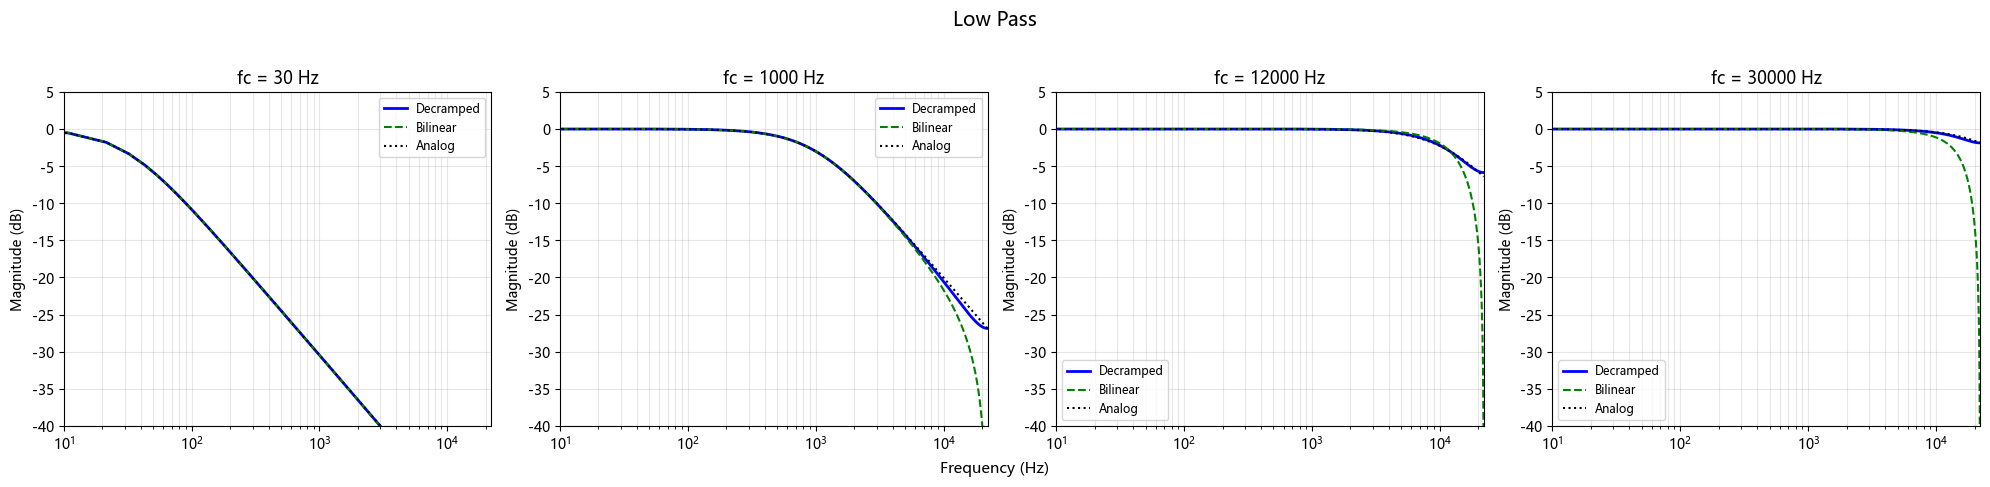

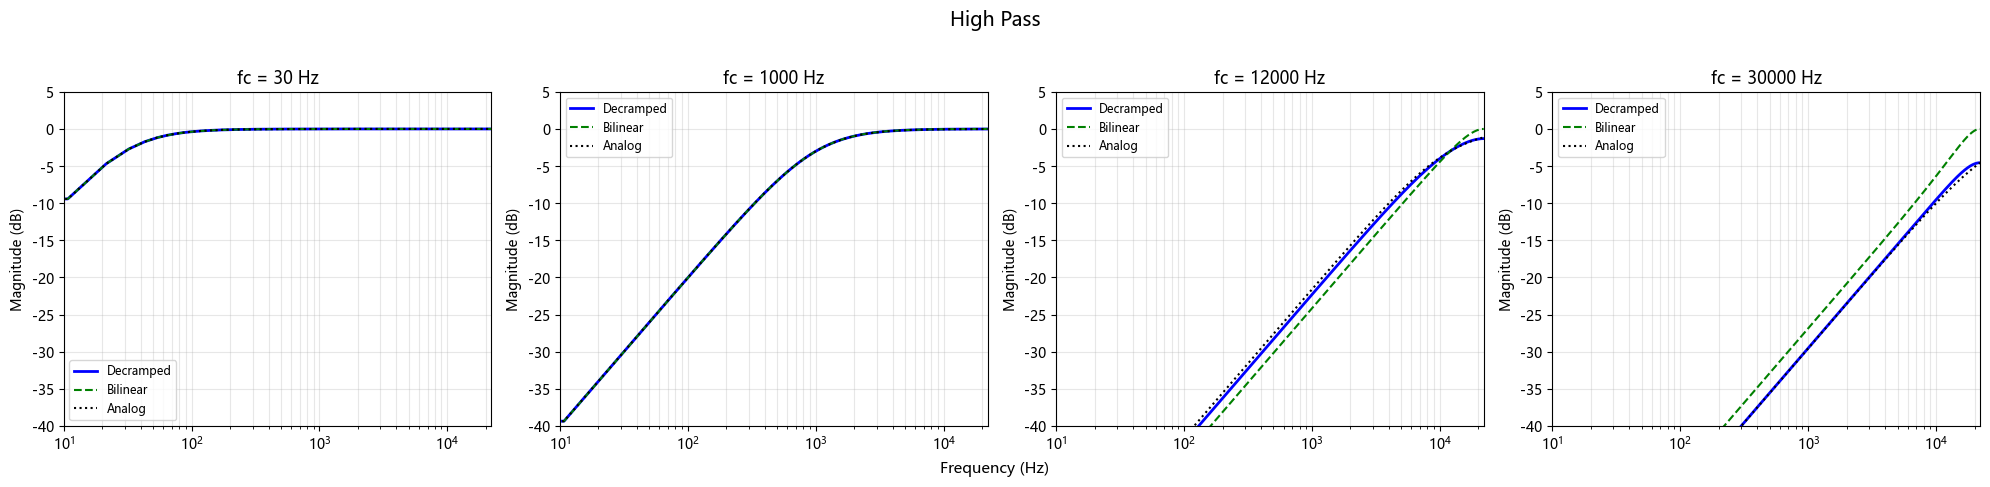

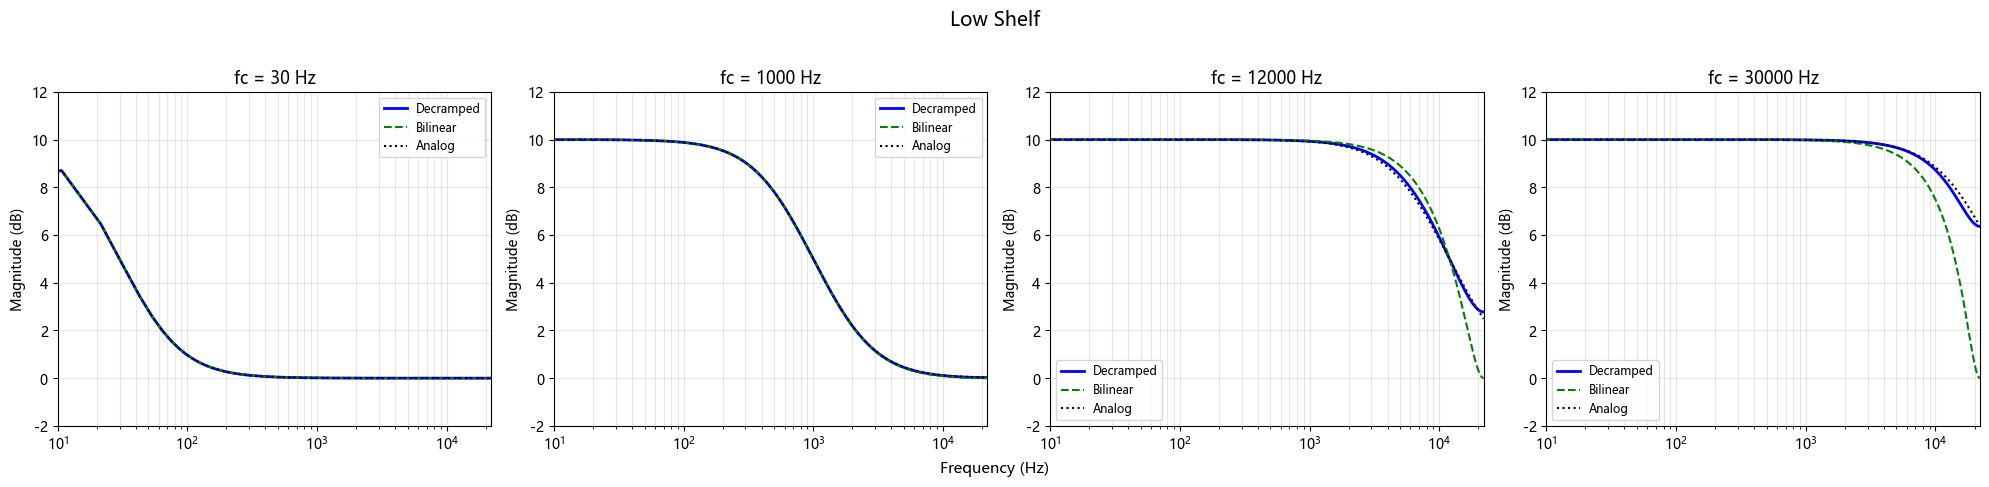

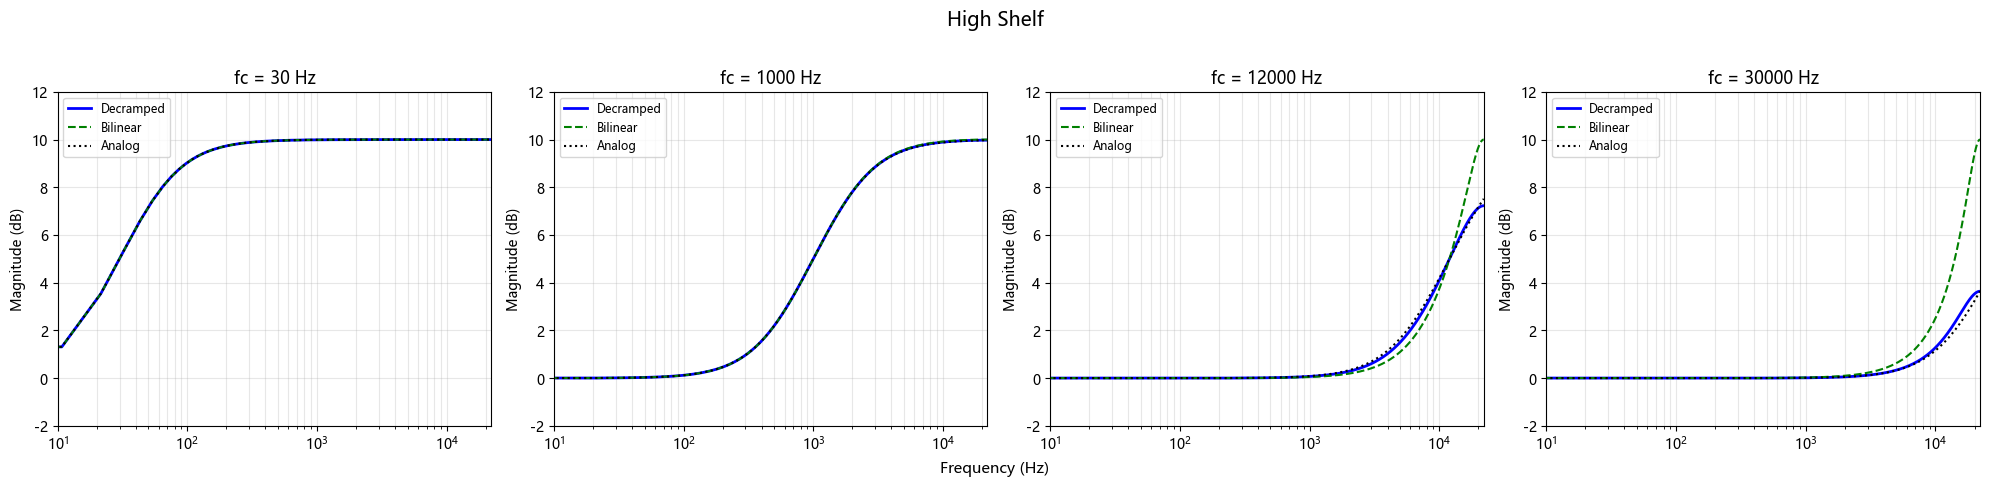

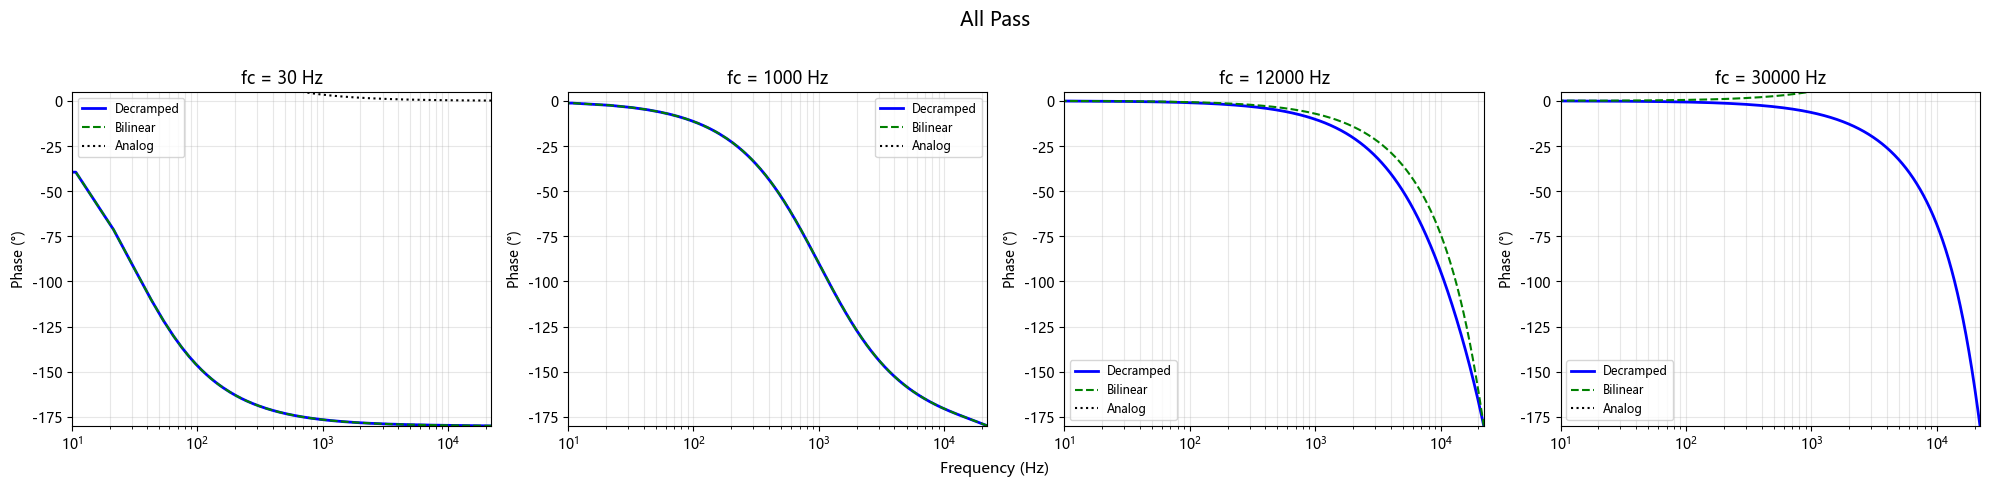

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# ==========================================
# 1. 核心算法实现 (根据论文 Table 2.1)
# ==========================================


def get_prewarped_omega(fc, fs, sigma):
    if fc > fs / 2:
        return fs / fc
    omega_raw = fs / fc
    ctg_val = 1.0 / np.tan(np.pi / omega_raw)
    denom = np.sqrt(sigma**2 + (np.pi * ctg_val) ** 2)
    return denom


def phi(x, sigma):
    if np.isinf(x):
        return -1.0
    val = np.sqrt(x**2 + sigma**2)
    return (np.pi - val) / (np.pi + val)


def get_first_order_coefficients(filter_type, fc, fs, sigma=2.0, gain_db=10.0):
    omega = get_prewarped_omega(fc, fs, sigma)
    g = 10 ** (gain_db / 20.0)
    alpha = 0.0
    beta = 0.0
    G = 0.0
    if filter_type.lower() in ["high pass", "hp"]:
        alpha = phi(np.inf, sigma)
        beta = phi(omega, sigma)
        G = omega / (2 * np.pi)
    elif filter_type.lower() in ["low pass", "lp"]:
        alpha = phi(0.0, sigma)
        beta = phi(omega, sigma)
        G = 1.0 / (1.0 + alpha)
    elif filter_type.lower() in ["all pass", "ap"]:
        beta = phi(omega, sigma)
        alpha = 1.0 / beta if beta != 0 else 0.0
        G = 1.0 / (1.0 + alpha)
    elif filter_type.lower() in ["high shelf", "hs"]:
        alpha = phi(omega * np.sqrt(g), sigma)
        beta = phi(omega * np.sqrt(1.0 / g), sigma)
        G = 1.0 / (1.0 + alpha)
    elif filter_type.lower() in ["low shelf", "ls"]:
        alpha = phi(omega * np.sqrt(1.0 / g), sigma)
        beta = phi(omega * np.sqrt(g), sigma)
        G = g / (1.0 + alpha)
    else:
        raise ValueError(f"Unknown filter type: {filter_type}")
    b0 = G * (1.0 + beta)
    b1 = G * (1.0 + beta) * alpha
    a0 = 1.0
    a1 = beta
    return [b0, b1], [a0, a1]


# ------------------------------------------------------------
# 模拟原型传递函数
# ------------------------------------------------------------


def get_analog_coefficients(filter_type, fc, gain_db=10.0):
    wc = 2.0 * np.pi * fc
    g = 10.0 ** (gain_db / 20.0)
    if filter_type.lower() in ["high pass", "hp"]:
        return [1.0, 0.0], [1.0, wc]
    elif filter_type.lower() in ["low pass", "lp"]:
        return [wc], [1.0, wc]
    elif filter_type.lower() in ["all pass", "ap"]:
        return [1.0, -wc], [1.0, wc]
    elif filter_type.lower() in ["low shelf", "ls"]:
        return [1.0, wc * np.sqrt(g)], [1.0, wc / np.sqrt(g)]
    elif filter_type.lower() in ["high shelf", "hs"]:
        return [g, wc * np.sqrt(g)], [1.0, wc * np.sqrt(g)]
    else:
        raise ValueError(f"Unknown filter type: {filter_type}")


# ------------------------------------------------------------
# 一阶双线性变换 (带频率预扭曲)
# ------------------------------------------------------------


def get_bilinear_first_order_coefficients(filter_type, fc, fs, gain_db=10.0):
    Omega_c = 2.0 * np.pi * fc
    Omega_warped = 2.0 * fs * np.tan(Omega_c / (2.0 * fs))
    A = 10.0 ** (gain_db / 20.0)
    t = filter_type.lower()
    if t in ["low pass", "lp"]:
        d = 2.0 * fs + Omega_warped
        return [Omega_warped / d, Omega_warped / d], [
            1.0,
            (Omega_warped - 2.0 * fs) / d,
        ]
    elif t in ["high pass", "hp"]:
        d = 2.0 * fs + Omega_warped
        return [2.0 * fs / d, -2.0 * fs / d], [1.0, (Omega_warped - 2.0 * fs) / d]
    elif t in ["all pass", "ap"]:
        d = 2.0 * fs + Omega_warped
        return [(Omega_warped - 2.0 * fs) / d, (Omega_warped + 2.0 * fs) / d], [
            1.0,
            (Omega_warped - 2.0 * fs) / d,
        ]
    elif t in ["low shelf", "ls"]:
        sA = np.sqrt(A)
        d = 2.0 * fs + Omega_warped / sA
        return [
            (2.0 * fs + A * Omega_warped / sA) / d,
            (-2.0 * fs + A * Omega_warped / sA) / d,
        ], [1.0, (-2.0 * fs + Omega_warped / sA) / d]
    elif t in ["high shelf", "hs"]:
        sA = np.sqrt(A)
        d = 2.0 * fs + sA * Omega_warped
        return [
            (2.0 * fs * A + sA * Omega_warped) / d,
            (-2.0 * fs * A + sA * Omega_warped) / d,
        ], [1.0, (-2.0 * fs + sA * Omega_warped) / d]
    else:
        raise ValueError(f"Unknown filter type: {filter_type}")


# ==========================================
# 2. 各滤波器类型分频率对比 (3 种设计方法)
# ==========================================

fs = 44100.0
fc_list = [30, 1000, 12000, 30000]
gain_db = 10.0
sigma = 2

filter_types = ["Low Pass", "High Pass", "Low Shelf", "High Shelf", "All Pass"]

for f_type in filter_types:
    fig, axes = plt.subplots(1, len(fc_list), figsize=(5 * len(fc_list), 4.5))

    for col, fc in enumerate(fc_list):
        ax = axes[col]

        b, a = get_first_order_coefficients(
            f_type, fc, fs, sigma=sigma, gain_db=gain_db
        )
        b_bl, a_bl = get_bilinear_first_order_coefficients(
            f_type, fc, fs, gain_db=gain_db
        )

        w, h = signal.freqz(b, a, worN=2048, fs=fs)
        _, h_bl = signal.freqz(b_bl, a_bl, worN=2048, fs=fs)

        b_an, a_an = get_analog_coefficients(f_type, fc, gain_db)
        _, h_an = signal.freqs(b_an, a_an, worN=w * 2.0 * np.pi)

        if f_type == "All Pass":
            ax.plot(w, np.angle(h) * 180 / np.pi, "b-", label="Decramped", linewidth=2)
            ax.plot(
                w, np.angle(h_bl) * 180 / np.pi, "g--", label="Bilinear", linewidth=1.5
            )
            ax.plot(
                w, np.angle(h_an) * 180 / np.pi, "k:", label="Analog", linewidth=1.5
            )
        else:
            ax.plot(
                w,
                20 * np.log10(np.maximum(np.abs(h), 1e-5)),
                "b-",
                label="Decramped",
                linewidth=2,
            )
            ax.plot(
                w,
                20 * np.log10(np.maximum(np.abs(h_bl), 1e-5)),
                "g--",
                label="Bilinear",
                linewidth=1.5,
            )
            ax.plot(
                w,
                20 * np.log10(np.maximum(np.abs(h_an), 1e-15)),
                "k:",
                label="Analog",
                linewidth=1.5,
            )

        ax.set_xscale("log")
        ax.set_xlim(10, fs / 2)
        ax.set_title(f"fc = {fc} Hz")
        ax.grid(True, which="both", alpha=0.3)
        ax.legend(fontsize="small")

        if f_type == "All Pass":
            ax.set_ylabel("Phase (°)")
            ax.set_ylim(-180, 5)
        else:
            ax.set_ylabel("Magnitude (dB)")
            if "Shelf" in f_type:
                ax.set_ylim(-2, gain_db + 2)
            else:
                ax.set_ylim(-40, 5)

    fig.suptitle(f_type, fontsize=14, y=1.02)
    fig.text(0.5, -0.01, "Frequency (Hz)", ha="center", fontsize=11)
    plt.tight_layout()
    plt.show()

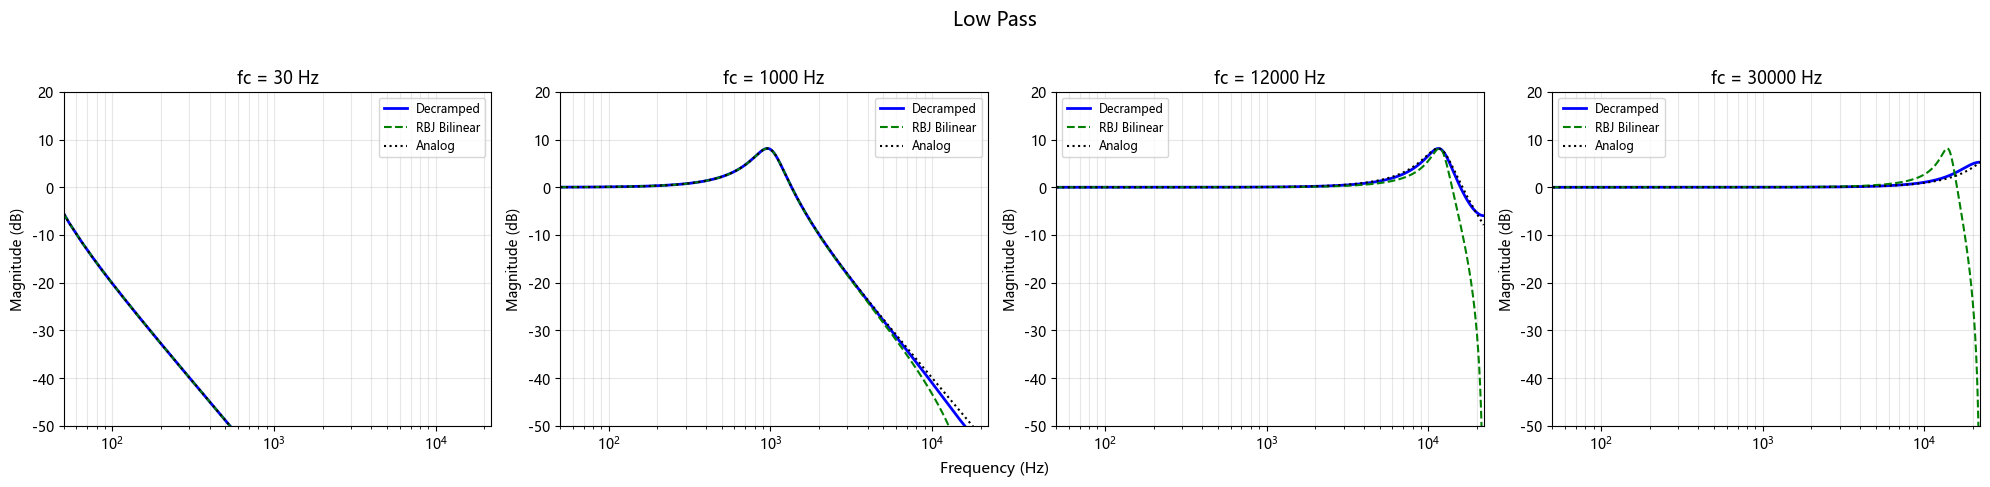

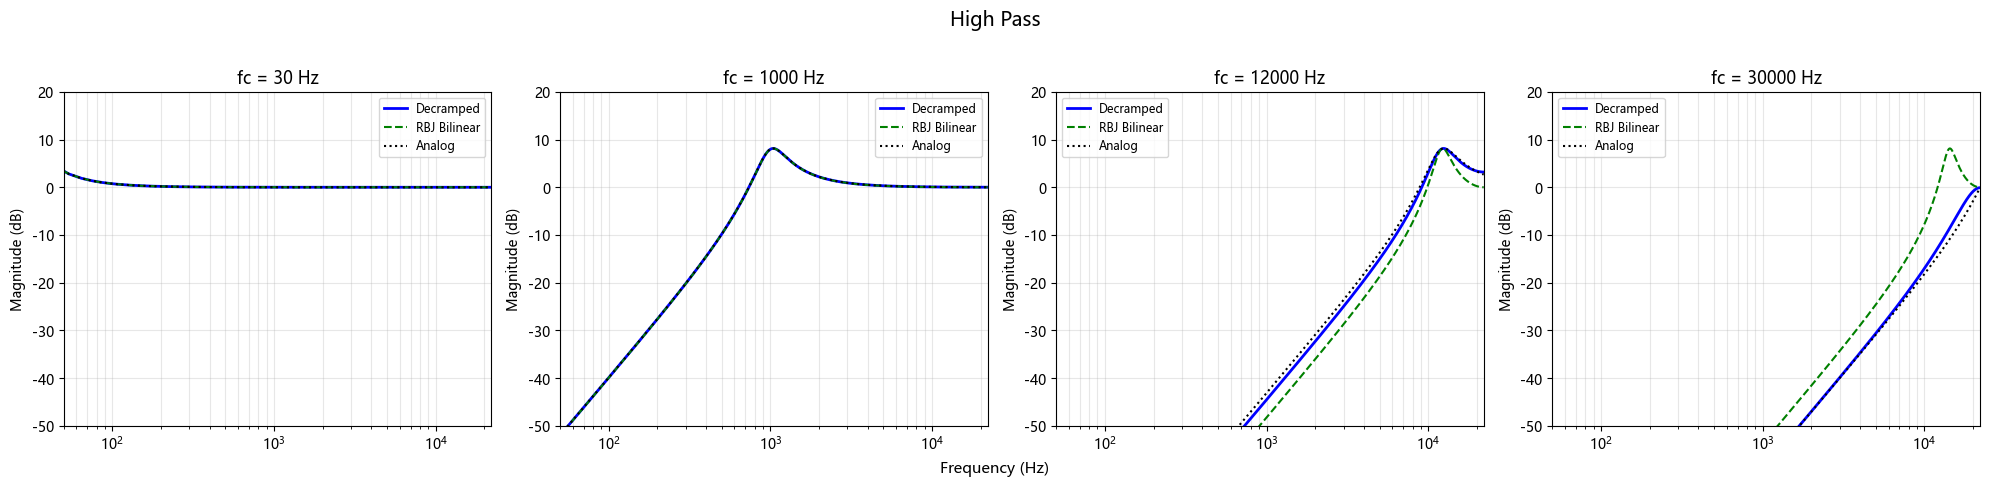

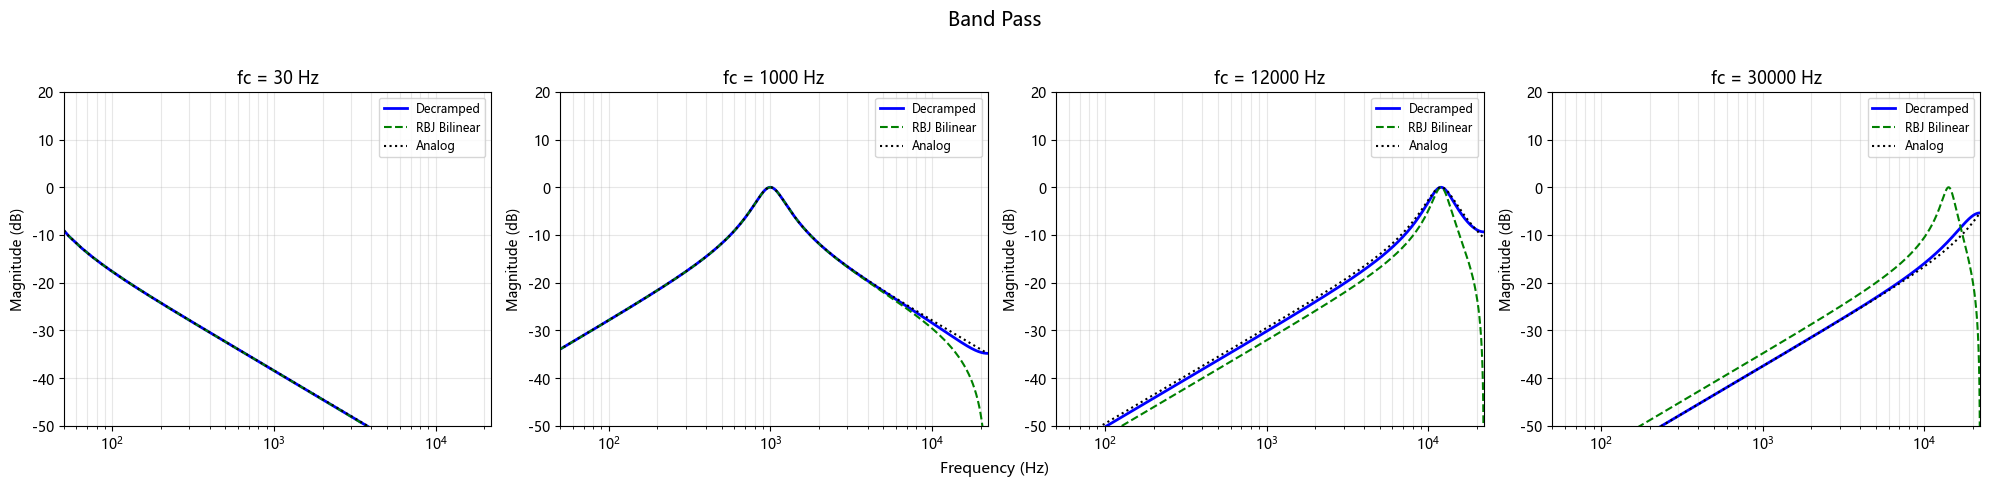

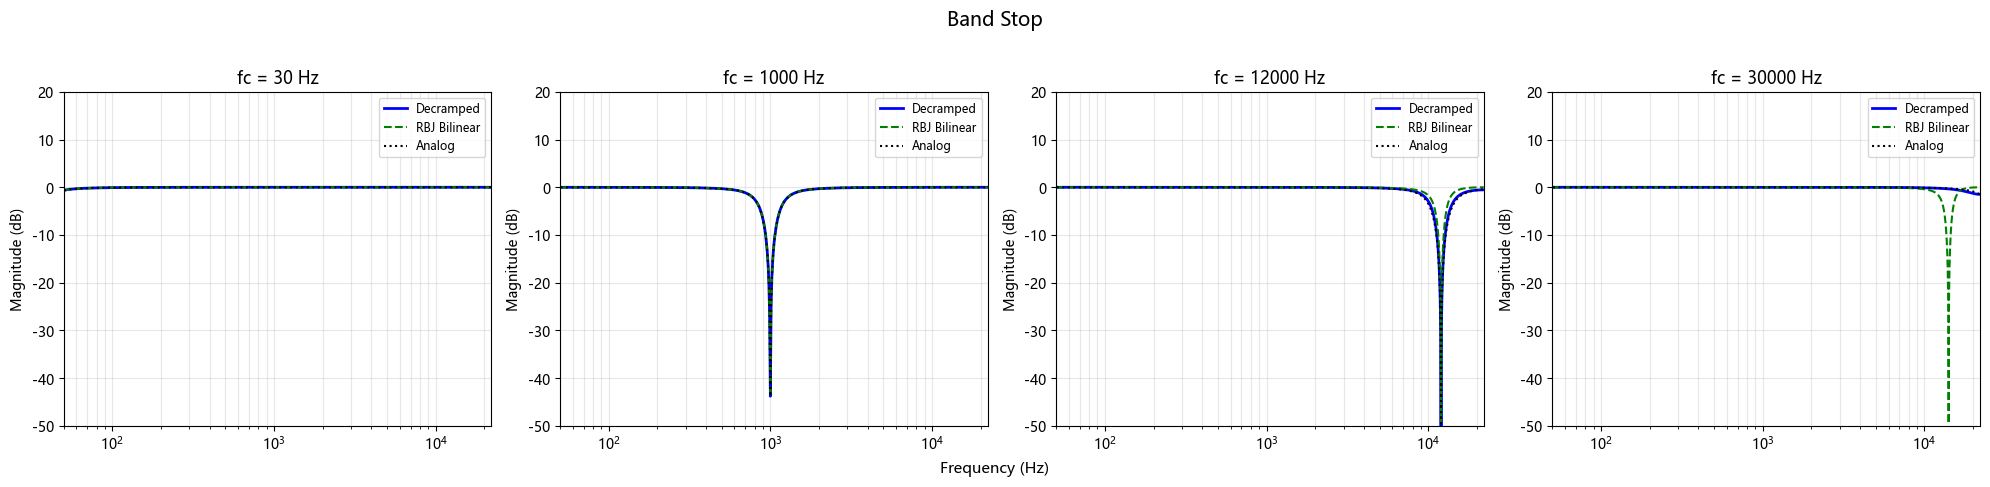

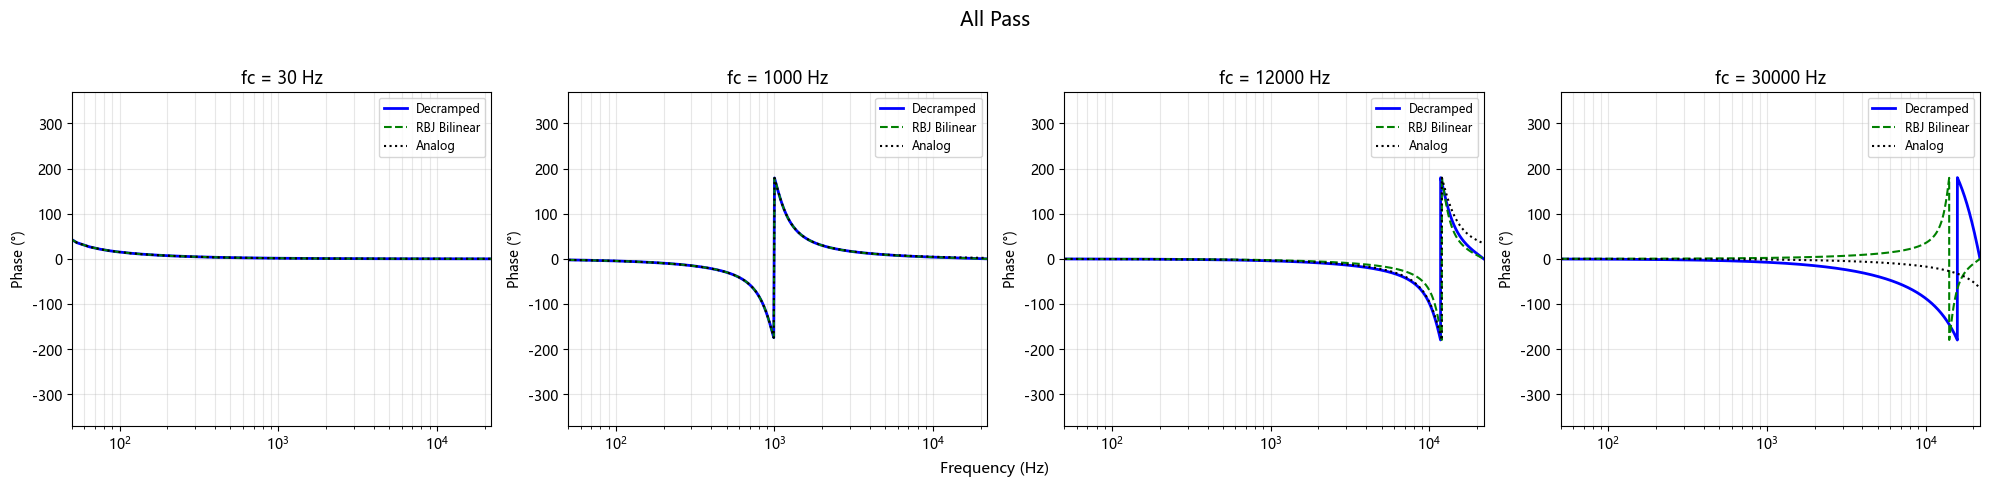

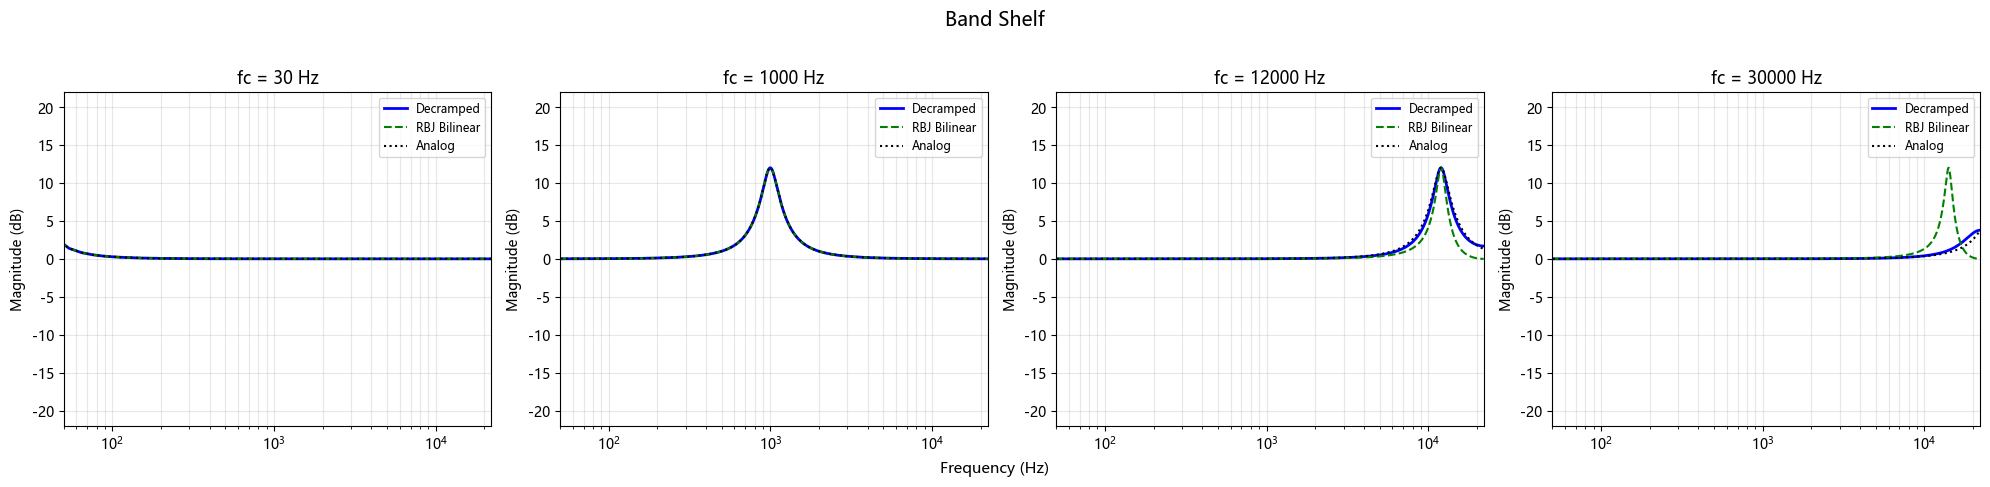

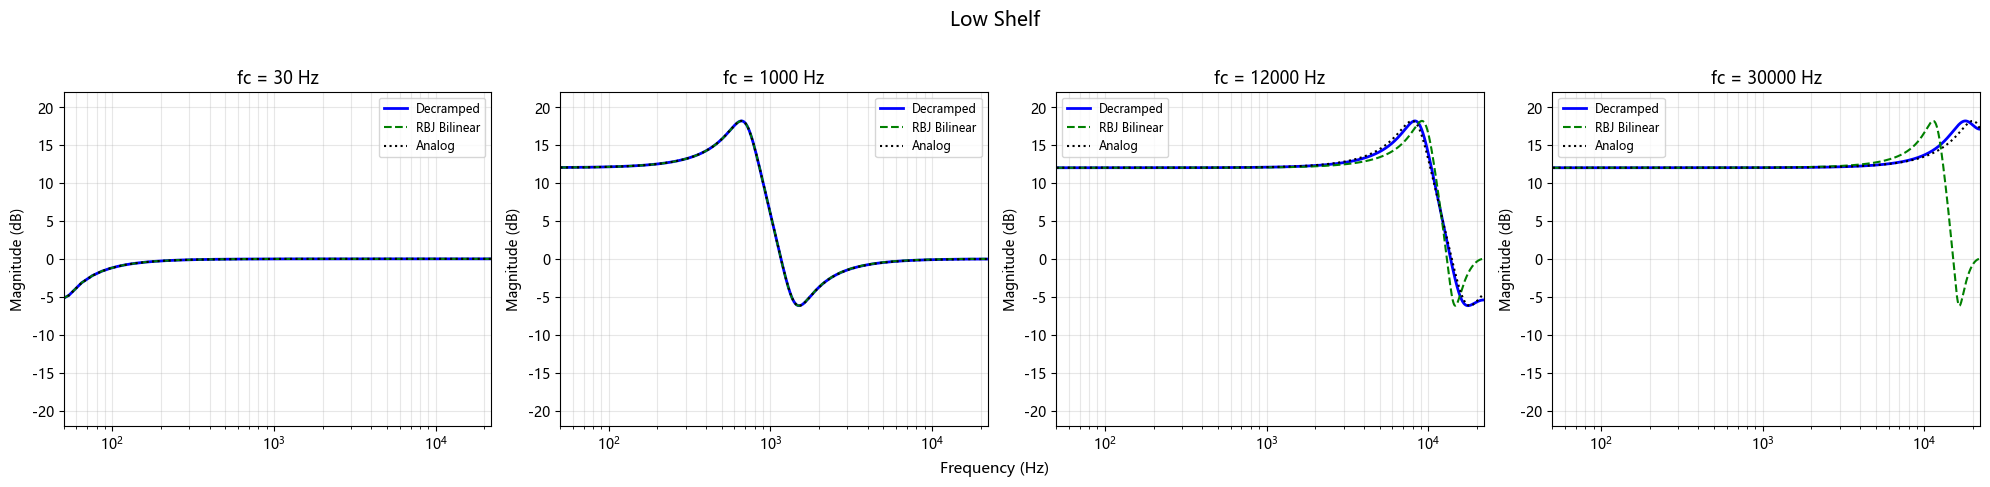

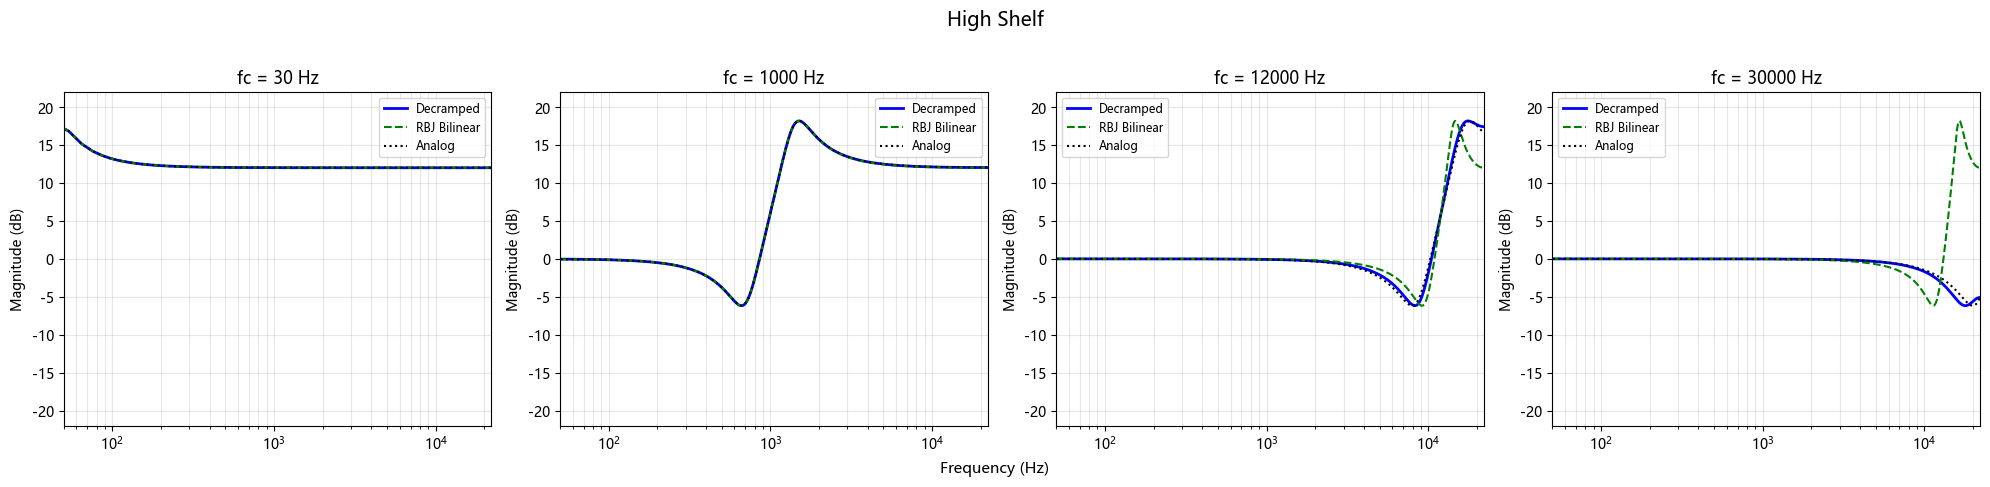

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

# ==========================================
# 1. 核心算法实现 (根据论文 Section 3)
# ==========================================


def phi_1st(x, sigma):
    if np.isinf(x):
        return -1.0
    val = np.sqrt(x**2 + sigma**2)
    return (np.pi - val) / (np.pi + val)


def nu(x, y, sigma):
    return np.sqrt(x**4 + 2 * (x**2) * (sigma**2) * (2 * y**2 - 1) + sigma**4)


def kappa(x, y, sigma):
    return x**2 * (2 * y**2 - 1) + sigma**2


def phi1_2nd(x, y, sigma):
    v_val = nu(x, y, sigma)
    k_val = kappa(x, y, sigma)
    denom = np.pi**2 + np.pi * np.sqrt(2) * np.sqrt(v_val + k_val) + v_val
    return (2 * np.pi**2 - 2 * v_val) / denom


def phi2_2nd(x, y, sigma):
    v_val = nu(x, y, sigma)
    k_val = kappa(x, y, sigma)
    denom = np.pi**2 + np.pi * np.sqrt(2) * np.sqrt(v_val + k_val) + v_val
    return (np.pi**2 - np.pi * np.sqrt(2) * np.sqrt(v_val + k_val) + v_val) / denom


def get_second_order_coefficients_v2(
    filter_type,
    fc,
    fs,
    zeta=1.0 / np.sqrt(2),
    sigma=2.0,
    gain_db=10.0,
    use_simplified_notch=True,
):
    omega = get_prewarped_omega(fc, fs, sigma)
    g = 10 ** (gain_db / 20.0)

    alpha1, alpha2 = 0.0, 0.0
    beta1, beta2 = 0.0, 0.0
    G = 0.0

    # 统一计算分母反馈系数 (所有二阶类型分母相同)
    beta1 = phi1_2nd(omega, zeta, sigma)
    beta2 = phi2_2nd(omega, zeta, sigma)

    if filter_type.lower() in ["band stop", "notch"]:
        if use_simplified_notch:
            # 采用论文公式 (3.9) 的高效简化版
            num = omega**2 - np.pi**2 - sigma**2
            denom_alpha = omega**2 + np.pi**2 - sigma**2
            alpha1 = -2.0 * (num / denom_alpha)
            alpha2 = 1.0
        else:
            # 采用 Table 3.1 的标准版: phi_1(omega, 0), phi_2(omega, 0)
            alpha1 = phi1_2nd(omega, 0.0, sigma)
            alpha2 = phi2_2nd(omega, 0.0, sigma)
        G = 1.0 / (1.0 + alpha1 + alpha2)
    elif filter_type.lower() in ["low pass", "lp"]:
        alpha1 = phi_1st(0.0, sigma) + phi_1st(0.0, sigma)
        alpha2 = phi_1st(0.0, sigma) * phi_1st(0.0, sigma)
        G = 1.0 / (1.0 + alpha1 + alpha2)
    elif filter_type.lower() in ["high pass", "hp"]:
        alpha1 = phi_1st(np.inf, sigma) + phi_1st(np.inf, sigma)
        alpha2 = phi_1st(np.inf, sigma) * phi_1st(np.inf, sigma)
        G = omega**2 / (4 * np.pi**2)
    elif filter_type.lower() in ["band pass", "bp"]:
        alpha1 = phi_1st(0.0, sigma) + phi_1st(np.inf, sigma)
        alpha2 = phi_1st(0.0, sigma) * phi_1st(np.inf, sigma)
        G = (omega / (2 * np.pi)) * (2 * zeta / (2 + alpha1))
    elif filter_type.lower() in ["band shelf", "bs"]:
        alpha1 = phi1_2nd(omega, zeta * g**0.5, sigma)
        alpha2 = phi2_2nd(omega, zeta * g**0.5, sigma)
        beta1 = phi1_2nd(omega, zeta * g**-0.5, sigma)
        beta2 = phi2_2nd(omega, zeta * g**-0.5, sigma)
        G = 1.0 / (1.0 + alpha1 + alpha2)
    elif filter_type.lower() in ["high shelf", "hs"]:
        alpha1 = phi1_2nd(omega * g**0.25, zeta, sigma)
        alpha2 = phi2_2nd(omega * g**0.25, zeta, sigma)
        G = 1.0 / (1.0 + alpha1 + alpha2)
        beta1 = phi1_2nd(omega * g**-0.25, zeta, sigma)
        beta2 = phi2_2nd(omega * g**-0.25, zeta, sigma)
    elif filter_type.lower() in ["low shelf", "ls"]:
        alpha1 = phi1_2nd(omega * g**-0.25, zeta, sigma)
        alpha2 = phi2_2nd(omega * g**-0.25, zeta, sigma)
        beta1 = phi1_2nd(omega * g**0.25, zeta, sigma)
        beta2 = phi2_2nd(omega * g**0.25, zeta, sigma)
        G = g / (1.0 + alpha1 + alpha2)
    elif filter_type.lower() in ["all pass", "ap"]:
        alpha1 = beta1 / beta2
        alpha2 = 1.0 / beta2
        G = 1.0 / (1.0 + alpha1 + alpha2)
    else:
        raise ValueError(f"Unsupported filter type: {filter_type}")

    # 还原传输函数系数
    scale = G * (1.0 + beta1 + beta2)
    b = [scale, scale * alpha1, scale * alpha2]
    a = [1.0, beta1, beta2]

    return b, a


# ==========================================
# 2. 模拟原型幅度响应计算 (用于对比)
# ==========================================


def get_analogue_magnitude_response(
    filter_type, f, fc, zeta=1.0 / np.sqrt(2), gain_db=10.0
):
    """计算二阶模拟原型在频率 f (Hz) 处的幅频响应 (绝对值)"""
    s = 1j * (f / fc)
    g = 10 ** (gain_db / 20.0)
    sg = np.sqrt(g)  # 10^(db/40), 参考中的 A
    fg = np.sqrt(sg)  # 10^(db/80), 参考中的 sqrt_A

    if filter_type.lower() in ["low pass", "lp"]:
        h_s = 1.0 / (s**2 + 2 * zeta * s + 1.0)
    elif filter_type.lower() in ["high pass", "hp"]:
        h_s = s**2 / (s**2 + 2 * zeta * s + 1.0)
    elif filter_type.lower() in ["band pass", "bp"]:
        h_s = 2 * zeta * s / (s**2 + 2 * zeta * s + 1.0)
    elif filter_type.lower() in ["band stop", "notch"]:
        h_s = (s**2 + 1.0) / (s**2 + 2 * zeta * s + 1.0)
    elif filter_type.lower() in ["all pass", "ap"]:
        h_s = (s**2 - 2 * zeta * s + 1.0) / (s**2 + 2 * zeta * s + 1.0)
    elif filter_type.lower() in ["band shelf", "peak"]:
        h_s = (s**2 + 2 * zeta * sg * s + 1.0) / (s**2 + 2 * zeta / sg * s + 1.0)
    elif filter_type.lower() in ["high shelf", "hs"]:
        # H(s) = A * (A*s² + sqrt_A/Q*s + 1) / (s² + sqrt_A/Q*s + A)
        # A = sg, sqrt_A = fg, Q = 1/(2*zeta)
        h_s = (
            sg * (sg * s**2 + fg * 2 * zeta * s + 1.0) / (s**2 + fg * 2 * zeta * s + sg)
        )
    elif filter_type.lower() in ["low shelf", "ls"]:
        # H(s) = A * (s² + sqrt_A/Q*s + A) / (A*s² + sqrt_A/Q*s + 1)
        h_s = (
            sg * (s**2 + fg * 2 * zeta * s + sg) / (sg * s**2 + fg * 2 * zeta * s + 1.0)
        )
    else:
        return np.ones_like(f)

    return np.abs(h_s)


# ------------------------------------------------------------
# 传统 RBJ 双二阶 (双线性变换 + 频率预扭曲)
# ------------------------------------------------------------


def get_rbj_coefficients(filter_type, fc, fs, zeta=1.0 / np.sqrt(2), gain_db=10.0):
    """
    计算标准 RBJ (Robert Bristow-Johnson) 双二阶滤波器系数。
    基于 Audio EQ Cookbook，使用双线性变换 + 频率预扭曲。
    """
    w0 = 2.0 * np.pi * fc / fs  # 归一化角频率
    cos_w0 = np.cos(w0)
    sin_w0 = np.sin(w0)
    Q = 1.0 / (2.0 * zeta)  # 品质因数 Q ↔ 阻尼系数 ζ
    alpha = sin_w0 / (2.0 * Q)  # RBJ alpha 参数
    A = 10.0 ** (gain_db / 40.0)  # RBJ 增益参数 (注意是 dB/40)

    if filter_type.lower() in ["low pass", "lp"]:
        b0 = (1.0 - cos_w0) / 2.0
        b1 = 1.0 - cos_w0
        b2 = (1.0 - cos_w0) / 2.0
        a0 = 1.0 + alpha
        a1 = -2.0 * cos_w0
        a2 = 1.0 - alpha
    elif filter_type.lower() in ["high pass", "hp"]:
        b0 = (1.0 + cos_w0) / 2.0
        b1 = -(1.0 + cos_w0)
        b2 = (1.0 + cos_w0) / 2.0
        a0 = 1.0 + alpha
        a1 = -2.0 * cos_w0
        a2 = 1.0 - alpha
    elif filter_type.lower() in ["band pass", "bp"]:
        b0 = alpha
        b1 = 0.0
        b2 = -alpha
        a0 = 1.0 + alpha
        a1 = -2.0 * cos_w0
        a2 = 1.0 - alpha
    elif filter_type.lower() in ["band stop", "notch"]:
        b0 = 1.0
        b1 = -2.0 * cos_w0
        b2 = 1.0
        a0 = 1.0 + alpha
        a1 = -2.0 * cos_w0
        a2 = 1.0 - alpha
    elif filter_type.lower() in ["all pass", "ap"]:
        b0 = 1.0 - alpha
        b1 = -2.0 * cos_w0
        b2 = 1.0 + alpha
        a0 = 1.0 + alpha
        a1 = -2.0 * cos_w0
        a2 = 1.0 - alpha
    elif filter_type.lower() in ["band shelf", "peak"]:
        b0 = 1.0 + alpha * A
        b1 = -2.0 * cos_w0
        b2 = 1.0 - alpha * A
        a0 = 1.0 + alpha / A
        a1 = -2.0 * cos_w0
        a2 = 1.0 - alpha / A
    elif filter_type.lower() in ["low shelf", "ls"]:
        sqrt_A = np.sqrt(A)
        b0 = A * ((A + 1.0) - (A - 1.0) * cos_w0 + 2.0 * sqrt_A * alpha)
        b1 = 2.0 * A * ((A - 1.0) - (A + 1.0) * cos_w0)
        b2 = A * ((A + 1.0) - (A - 1.0) * cos_w0 - 2.0 * sqrt_A * alpha)
        a0 = (A + 1.0) + (A - 1.0) * cos_w0 + 2.0 * sqrt_A * alpha
        a1 = -2.0 * ((A - 1.0) + (A + 1.0) * cos_w0)
        a2 = (A + 1.0) + (A - 1.0) * cos_w0 - 2.0 * sqrt_A * alpha
    elif filter_type.lower() in ["high shelf", "hs"]:
        sqrt_A = np.sqrt(A)
        b0 = A * ((A + 1.0) + (A - 1.0) * cos_w0 + 2.0 * sqrt_A * alpha)
        b1 = -2.0 * A * ((A - 1.0) + (A + 1.0) * cos_w0)
        b2 = A * ((A + 1.0) + (A - 1.0) * cos_w0 - 2.0 * sqrt_A * alpha)
        a0 = (A + 1.0) - (A - 1.0) * cos_w0 + 2.0 * sqrt_A * alpha
        a1 = 2.0 * ((A - 1.0) - (A + 1.0) * cos_w0)
        a2 = (A + 1.0) - (A - 1.0) * cos_w0 - 2.0 * sqrt_A * alpha
    else:
        raise ValueError(f"Unknown filter type: {filter_type}")

    # 归一化使 a0 = 1
    b = [b0 / a0, b1 / a0, b2 / a0]
    a = [1.0, a1 / a0, a2 / a0]
    return b, a


# ==========================================
# 3. 各滤波器类型分频率对比 (二阶)
# ==========================================

fs = 44100.0
fc_list = [30, 1000, 12000, 30000]
zeta = 0.2
gain_db = 12.0
sigma = 2

filter_types = [
    "Low Pass",
    "High Pass",
    "Band Pass",
    "Band Stop",
    "All Pass",
    "Band Shelf",
    "Low Shelf",
    "High Shelf",
]

for f_type in filter_types:
    fig, axes = plt.subplots(1, len(fc_list), figsize=(5 * len(fc_list), 4.5))

    for col, fc in enumerate(fc_list):
        ax = axes[col]

        b, a = get_second_order_coefficients_v2(
            f_type, fc, fs, zeta=zeta, sigma=sigma, gain_db=gain_db
        )
        b_rbj, a_rbj = get_rbj_coefficients(f_type, fc, fs, zeta=zeta, gain_db=gain_db)

        w, h = signal.freqz(b, a, worN=2048, fs=fs)
        _, h_rbj = signal.freqz(b_rbj, a_rbj, worN=2048, fs=fs)

        h_ana = get_analogue_magnitude_response(
            f_type, w, fc, zeta=zeta, gain_db=gain_db
        )

        if f_type == "All Pass":
            ax.plot(w, np.angle(h) * 180 / np.pi, "b-", label="Decramped", linewidth=2)
            ax.plot(
                w,
                np.angle(h_rbj) * 180 / np.pi,
                "g--",
                label="RBJ Bilinear",
                linewidth=1.5,
            )
            s_val = 1j * (w / fc)
            h_ana_cplx = (s_val**2 - 2 * zeta * s_val + 1.0) / (
                s_val**2 + 2 * zeta * s_val + 1.0
            )
            ax.plot(
                w,
                np.angle(h_ana_cplx) * 180 / np.pi,
                "k:",
                label="Analog",
                linewidth=1.5,
            )
        else:
            ax.plot(
                w,
                20 * np.log10(np.maximum(np.abs(h), 1e-5)),
                "b-",
                label="Decramped",
                linewidth=2,
            )
            ax.plot(
                w,
                20 * np.log10(np.maximum(np.abs(h_rbj), 1e-5)),
                "g--",
                label="RBJ Bilinear",
                linewidth=1.5,
            )
            ax.plot(
                w,
                20 * np.log10(np.maximum(h_ana, 1e-5)),
                "k:",
                label="Analog",
                linewidth=1.5,
            )

        ax.set_xscale("log")
        ax.set_xlim(50, fs / 2)
        ax.set_title(f"fc = {fc} Hz")
        ax.grid(True, which="both", alpha=0.3)
        ax.legend(fontsize="small")

        if f_type == "All Pass":
            ax.set_ylabel("Phase (°)")
            ax.set_ylim(-370, 370)
        else:
            ax.set_ylabel("Magnitude (dB)")
            if "Shelf" in f_type or "Band Shelf" in f_type:
                ax.set_ylim(-gain_db - 10, gain_db + 10)
            else:
                ax.set_ylim(-50, 20)

    fig.suptitle(f_type, fontsize=14, y=1.02)
    fig.text(0.5, -0.01, "Frequency (Hz)", ha="center", fontsize=11)
    plt.tight_layout()
    plt.show()

# review get_prewarped_omega
fc = fs/2附近时，tan会返回非常巨大的数据甚至inf
fc = 0附近时，似乎也会返回非常巨大的数据

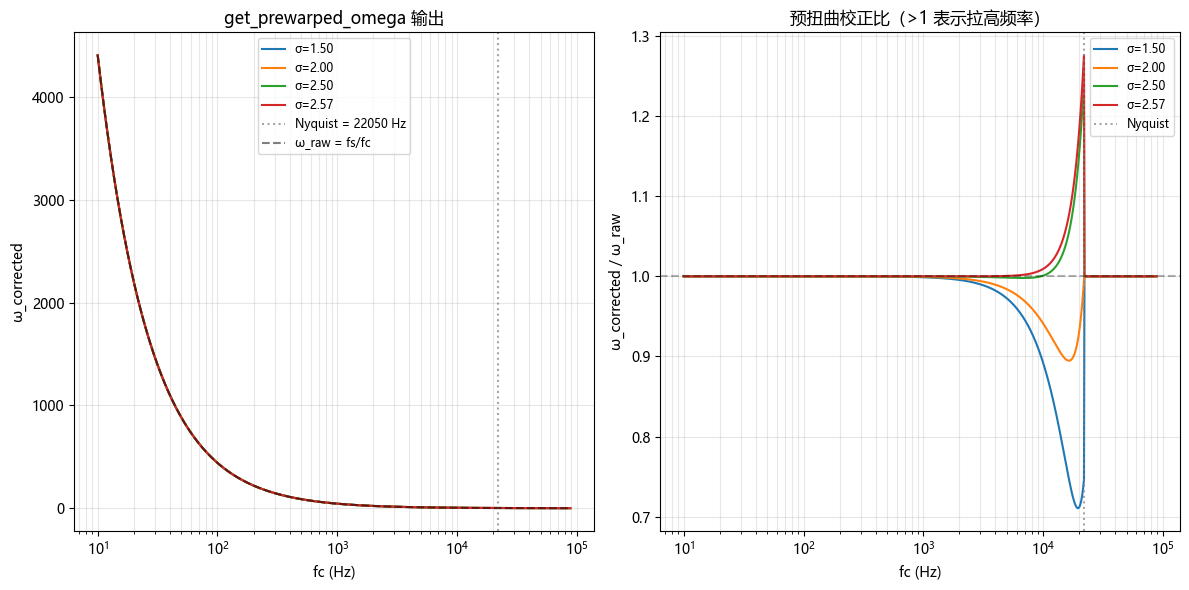

In [ ]:
# ==========================================
# 绘制 get_prewarped_omega 的形状
# ==========================================

fs = 44100.0
fc_range = np.logspace(1, np.log10(fs * 2), 1000)  # 10Hz ~ 2*fs (超出 Nyquist)

sigma_values = [1.5, 2.0, 2.5, np.pi * np.sqrt(2.0 / 3.0)]

plt.figure(figsize=(12, 6))

# ----- 子图 1: omega_corrected vs fc -----
plt.subplot(1, 2, 1)
for sigma in sigma_values:
    omega_corrected = np.array([get_prewarped_omega(fc, fs, sigma) for fc in fc_range])
    plt.plot(fc_range, omega_corrected, label=f"σ={sigma:.2f}")

# 标注 Nyquist 边界
plt.axvline(
    fs / 2, color="gray", linestyle=":", alpha=0.7, label=f"Nyquist = {fs / 2:.0f} Hz"
)
# 标注原始 omega = fs/fc
omega_raw = fs / fc_range
plt.plot(fc_range, omega_raw, "k--", alpha=0.5, label="ω_raw = fs/fc")

plt.xscale("log")
plt.xlabel("fc (Hz)")
plt.ylabel("ω_corrected")
plt.title("get_prewarped_omega 输出")
plt.legend(fontsize="small")
plt.grid(True, which="both", alpha=0.3)

# ----- 子图 2: 比值 omega_corrected / omega_raw -----
plt.subplot(1, 2, 2)
for sigma in sigma_values:
    omega_corrected = np.array([get_prewarped_omega(fc, fs, sigma) for fc in fc_range])
    ratio = omega_corrected / omega_raw
    plt.plot(fc_range, ratio, label=f"σ={sigma:.2f}")

plt.axvline(fs / 2, color="gray", linestyle=":", alpha=0.7, label="Nyquist")
plt.axhline(1.0, color="k", linestyle="--", alpha=0.3)

plt.xscale("log")
plt.xlabel("fc (Hz)")
plt.ylabel("ω_corrected / ω_raw")
plt.title("预扭曲校正比（>1 表示拉高频率）")
plt.legend(fontsize="small")
plt.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()


看一下w被扭曲到了什么地方，绘制一下输入频率(模拟)和输出频率(数字)

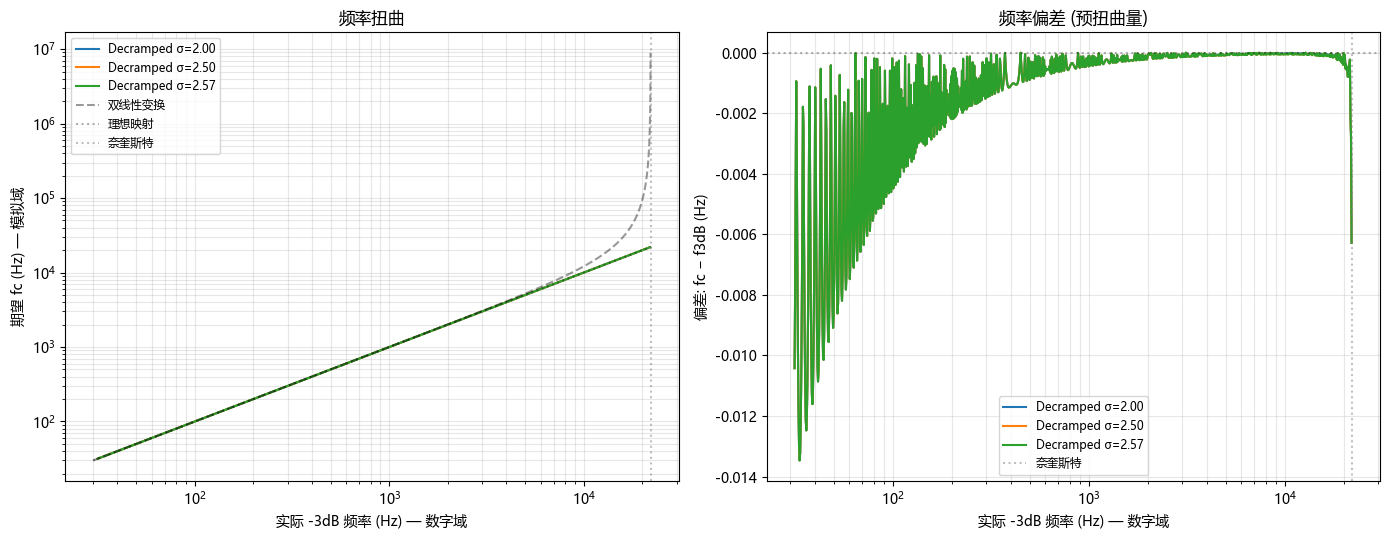

In [ ]:
# ==========================================
# 频率扭曲：数字 -3dB 频率 → 对应的模拟 fc
# ==========================================

fs = 44100.0
fc_range = np.logspace(1.5, np.log10(fs / 2), 1000)

sigma_values = [2.0, 2.5, np.pi * np.sqrt(2.0 / 3.0)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# ----- 标准双线性变换参考数据 -----
fd_bilinear = np.linspace(30, fs / 2 * 0.999, 1000)
fc_bilinear = fs / np.pi * np.tan(np.pi * fd_bilinear / fs)

# ----- Decramped 数据 -----
decramped_data = {}  # sigma -> (f3db_list, fc_valid, fc_invalid)
for sigma in sigma_values:
    f3db_list = []
    fc_valid = []
    fc_invalid = []
    for fc in fc_range:
        b, a = get_first_order_coefficients("low pass", fc, fs, sigma=sigma)
        w_grid, h = signal.freqz(b, a, worN=8192, fs=fs)
        mag = np.abs(h)
        idx = np.argmax(mag < 1.0 / np.sqrt(2.0))
        if idx > 0 and mag[0] >= 1.0 / np.sqrt(2.0):
            # 有效 -3dB 点：插值提高精度
            x0, x1 = w_grid[idx - 1], w_grid[idx]
            y0, y1 = mag[idx - 1], mag[idx]
            target = 1.0 / np.sqrt(2.0)
            f3db = x0 + (x1 - x0) * (target - y0) / (y1 - y0)
            f3db_list.append(f3db)
            fc_valid.append(fc)
        else:
            fc_invalid.append(fc)
    decramped_data[sigma] = (f3db_list, fc_valid, fc_invalid)

# ========== 图 1: 频率映射 ==========
for sigma, (f3db_list, fc_valid, _) in decramped_data.items():
    ax1.plot(f3db_list, fc_valid, label=f"Decramped σ={sigma:.2f}")

ax1.plot(fd_bilinear, fc_bilinear, "k--", alpha=0.4, label="双线性变换")
ax1.plot([30, fs / 2], [30, fs / 2], "k:", alpha=0.3, label="理想映射")
ax1.axvline(fs / 2, color="gray", linestyle=":", alpha=0.5, label="奈奎斯特")

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel("实际 -3dB 频率 (Hz) — 数字域")
ax1.set_ylabel("期望 fc (Hz) — 模拟域")
ax1.set_title("频率扭曲")
ax1.legend(fontsize="small")
ax1.grid(True, which="both", alpha=0.3)

# ========== 图 2: 频率偏差 ==========
# 偏差 = desired_fc - actual_f3db（正值表示模拟频率被拉高）
for sigma, (f3db_list, fc_valid, _) in decramped_data.items():
    deviation = np.array(fc_valid) - np.array(f3db_list)
    ax2.plot(f3db_list, deviation, label=f"Decramped σ={sigma:.2f}")

ax2.axhline(0, color="k", linestyle=":", alpha=0.3)
ax2.axvline(fs / 2, color="gray", linestyle=":", alpha=0.5, label="奈奎斯特")

ax2.set_xscale("log")
ax2.set_xlabel("实际 -3dB 频率 (Hz) — 数字域")
ax2.set_ylabel("偏差: fc − f3dB (Hz)")
ax2.set_title("频率偏差 (预扭曲量)")
ax2.legend(fontsize="small")
ax2.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

额，怎么可能是这样比呢。应该比较模拟滤波器响应和decramp滤波器响应的匹配度。  
如何比较：  
    x轴： 滤波器的截止频率 从低频到高频最后到超过奈奎斯特频率  
    y轴： 使用某种指标描述设计出的数字滤波器与模拟滤波器在[0,fs/2]范围内的幅度偏差  

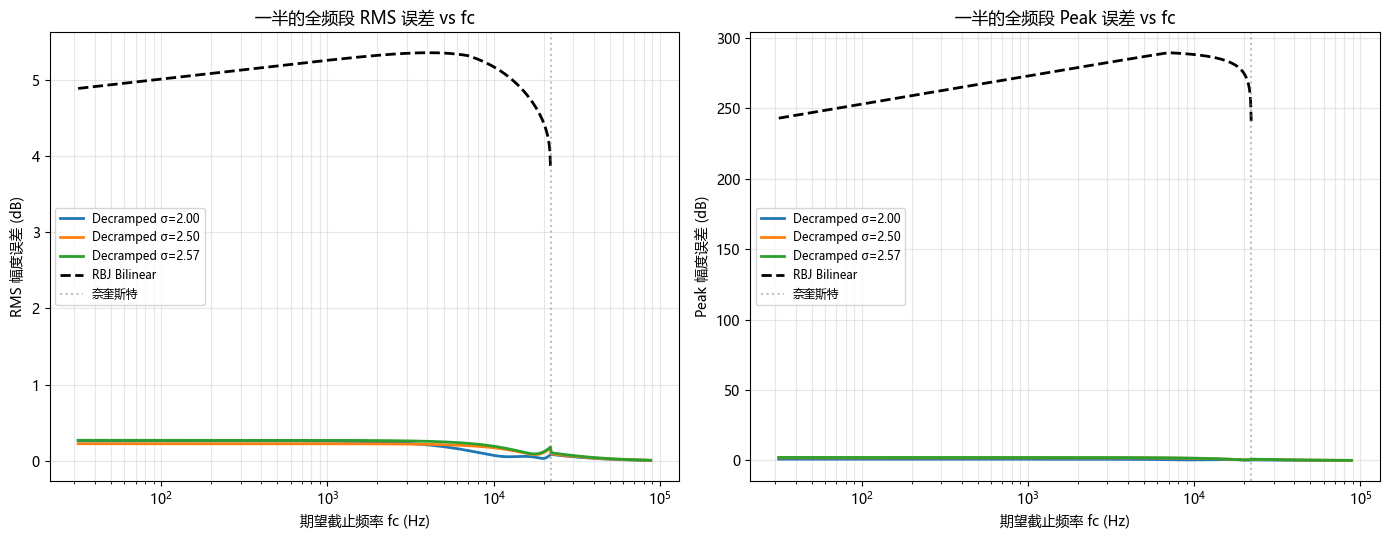

In [ ]:
# ==========================================
# 幅度匹配度 vs 截止频率 (一阶 Low Pass)
# ==========================================

fs = 44100.0
fc_range = np.logspace(1.5, np.log10(fs * 2), 1024)  # 30Hz ~ 2*fs

sigma_values = [2.0, 2.5, np.pi * np.sqrt(2.0 / 3.0)]

# 用于计算误差的频率网格 (0 ~ fs/2)
freq_grid = np.logspace(1, np.log10(fs / 2), 4096)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# ----- 收集 Decramped 数据 -----
for sigma in sigma_values:
    fc_valid = []
    rms_list = []
    peak_list = []
    for fc in fc_range:
        b, a = get_first_order_coefficients("low pass", fc, fs, sigma=sigma)
        b_an, a_an = get_analog_coefficients("low pass", fc)

        _, h_dig = signal.freqz(b, a, worN=freq_grid, fs=fs)
        _, h_ana = signal.freqs(b_an, a_an, worN=freq_grid * 2 * np.pi)

        mag_dig = 20 * np.log10(np.maximum(np.abs(h_dig), 1e-15))
        mag_ana = 20 * np.log10(np.maximum(np.abs(h_ana), 1e-15))

        if np.all(np.isinf(mag_dig)) or np.all(np.isinf(mag_ana)):
            continue

        err = mag_dig - mag_ana
        rms = np.sqrt(np.nanmean(err**2))
        peak = np.nanmax(np.abs(err))

        fc_valid.append(fc)
        rms_list.append(rms)
        peak_list.append(peak)

    ax1.plot(fc_valid, rms_list, label=f"Decramped σ={sigma:.2f}", linewidth=2)
    ax2.plot(fc_valid, peak_list, label=f"Decramped σ={sigma:.2f}", linewidth=2)

# ----- RBJ 基线 -----
fc_valid_rbj = []
rms_list_rbj = []
peak_list_rbj = []
for fc in fc_range:
    if fc >= fs / 2:
        continue
    b_rbj, a_rbj = get_bilinear_first_order_coefficients("low pass", fc, fs)
    b_an, a_an = get_analog_coefficients("low pass", fc)

    _, h_dig = signal.freqz(b_rbj, a_rbj, worN=freq_grid, fs=fs)
    _, h_ana = signal.freqs(b_an, a_an, worN=freq_grid * 2 * np.pi)

    mag_dig = 20 * np.log10(np.maximum(np.abs(h_dig), 1e-15))
    mag_ana = 20 * np.log10(np.maximum(np.abs(h_ana), 1e-15))

    if np.all(np.isinf(mag_dig)) or np.all(np.isinf(mag_ana)):
        continue

    err = mag_dig - mag_ana
    rms_list_rbj.append(np.sqrt(np.nanmean(err**2)))
    peak_list_rbj.append(np.nanmax(np.abs(err)))
    fc_valid_rbj.append(fc)

ax1.plot(fc_valid_rbj, rms_list_rbj, "k--", label="RBJ Bilinear", linewidth=2)
ax2.plot(fc_valid_rbj, peak_list_rbj, "k--", label="RBJ Bilinear", linewidth=2)

# 图 1 格式
ax1.axvline(fs / 2, color="gray", linestyle=":", alpha=0.5, label="奈奎斯特")
ax1.set_xscale("log")
# ax1.set_ylim(0, 0.3)
ax1.set_xlabel("期望截止频率 fc (Hz)")
ax1.set_ylabel("RMS 幅度误差 (dB)")
ax1.set_title("一半的全频段 RMS 误差 vs fc")
ax1.legend(fontsize="small")
ax1.grid(True, which="both", alpha=0.3)

# 图 2 格式
ax2.axvline(fs / 2, color="gray", linestyle=":", alpha=0.5, label="奈奎斯特")
ax2.set_xscale("log")
# ax2.set_ylim(0, 3)
ax2.set_xlabel("期望截止频率 fc (Hz)")
ax2.set_ylabel("Peak 幅度误差 (dB)")
ax2.set_title("一半的全频段 Peak 误差 vs fc")
ax2.legend(fontsize="small")
ax2.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()